# 深度学习原理入门：MNIST 手写数字识别

本 Notebook 用最简单的任务——识别 28x28 的手写数字——逐步拆解深度学习模型的工作原理：

1. 数据长什么样
2. 一个神经元在做什么
3. 全连接网络（MLP）
4. 训练的四步：前向、损失、反向、更新
5. 评估：准确率与混淆矩阵
6. 打开黑盒：网络学到了什么
7. 卷积网络（CNN）为什么更擅长看图
8. 总结与制造场景延伸

## 0. 准备

首次运行前，请确认已经在项目根目录执行过 `setup.bat` 安装了依赖，并且当前 Notebook 的内核选的是项目的 `.venv`。

下面这格代码会导入所有需要的库。

In [1]:
import os
import sys
from pathlib import Path

# ?????????????????????? requirements.txt ????
while not (Path.cwd() / "requirements.txt").exists():
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

os.environ["IN_NOTEBOOK"] = "1"   # ??????? Notebook ?????

import matplotlib.pyplot as plt
import torch

from src.data import get_loaders, denormalize
from src.model import build_model
from src.evaluate import (
    plot_history,
    plot_confusion_matrix,
    plot_mlp_weights,
    plot_cnn_filters_and_features,
)

print("?????:", Path.cwd())
print("PyTorch ??:", torch.__version__)
print("???? GPU:", torch.cuda.is_available())

?????: D:\ai\mnist_intro
PyTorch ??: 2.13.0+cpu
???? GPU: False


## 1. 数据长什么样

MNIST 是深度学习最经典的数据集：6 万张训练图 + 1 万张测试图，每张都是 28x28 的灰度手写数字，标注 0~9。

**对计算机来说，一张图就是一个 28x28=784 个数字的表格**，每个数字表示该像素的深浅（0=黑，255=白）。

In [2]:
train_loader, test_loader = get_loaders("data", batch_size=64)
print(f"训练集: {len(train_loader.dataset)} 张, 测试集: {len(test_loader.dataset)} 张")
print(f"每批 {train_loader.batch_size} 张，训练集共 {len(train_loader)} 批")

训练集: 60000 张, 测试集: 10000 张
每批 64 张，训练集共 938 批


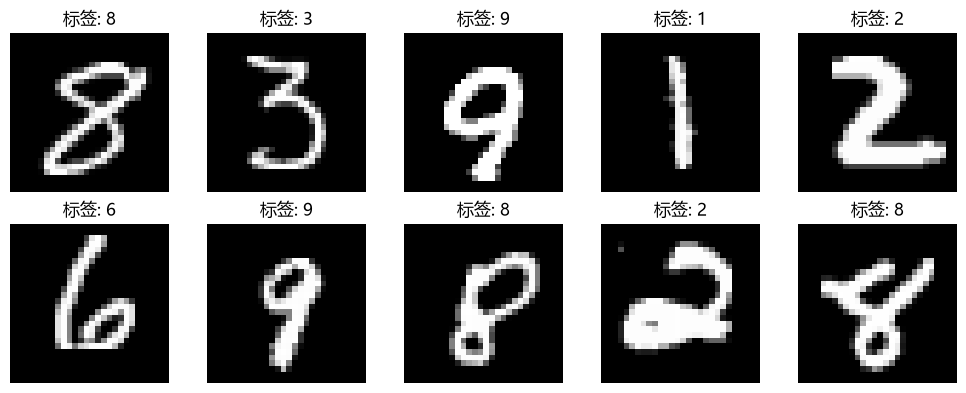

In [3]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(denormalize(img).squeeze(), cmap="gray")
    ax.set_title(f"标签: {label.item()}")
    ax.axis("off")
plt.tight_layout()

## 2. 一个神经元在做什么

神经元是神经网络的最小单元，它做的事可以概括为一句话：

> **把 784 个像素值各自乘上一个权重，再加起来，然后过一个激活函数。**

权重就是模型要学的“旋钮”。一开始这些旋钮是随机的，模型完全瞎猜；训练的过程就是反复微调这些旋钮，让输出越来越接近正确答案。

## 3. 全连接网络（MLP）

把很多神经元分层连接起来，就是全连接网络。我们的 MLP 结构很简单：

```
784 个输入像素 → 128 个神经元（中间层）→ 10 个输出（0~9 的得分）
```

输出的 10 个得分里，哪个数字得分最高，模型就认为图片是几。

In [4]:
mlp = build_model("mlp")
print(mlp)
print("可训练参数:", f"{sum(p.numel() for p in mlp.parameters()):,}", "个")

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
可训练参数: 101,770 个


## 4. 训练的四步：前向、损失、反向、更新

训练一个模型其实只有四个动作，不断重复：

1. **前向传播**：把图片喂给模型，得到预测；
2. **算损失**：用损失函数量化“预测离正确答案差多远”；
3. **反向传播**：算出每个权重应该往哪个方向调、调多少，才能减少损失；
4. **更新参数**：按学习率把权重微调一步。

下面用 8 张图跑 5 步，你可以看到损失（误差）在一点点变小。

In [5]:
import torch.nn as nn
import torch.optim as optim

sample, target = next(iter(train_loader))
sample, target = sample[:8], target[:8]   # 只取 8 张，跑得快

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.01)

for step in range(5):
    optimizer.zero_grad()
    outputs = mlp(sample)              # 1. 前向传播
    loss = criterion(outputs, target)  # 2. 算损失
    loss.backward()                    # 3. 反向传播
    optimizer.step()                   # 4. 更新参数
    print(f"step {step + 1}: loss = {loss.item():.4f}")

step 1: loss = 2.2721
step 2: loss = 2.0518
step 3: loss = 1.8567
step 4: loss = 1.6844
step 5: loss = 1.5286


## 5. 正式训练 MLP

刚才只是演示，下面在**全部 6 万张图**上正式训练（也可以直接加载已经训练好的模型，跳过训练）。

训练时的关键超参数：学习率 `lr`（每次调旋钮的幅度）、`epochs`（把全部数据过几遍）。

In [6]:
from pathlib import Path

ckpt = Path("outputs/mlp_mnist.pth")
if ckpt.exists():
    mlp.load_state_dict(torch.load(ckpt, map_location="cpu"))
    print("已加载预训练模型 outputs/mlp_mnist.pth（跳过训练）")
else:
    from src.train import train
    import argparse
    mlp, history = train(argparse.Namespace(
        model="mlp", epochs=3, batch_size=64, lr=1e-3,
        seed=42, data_dir="data", output_dir="outputs",
    ))
    plot_history(history, "outputs", "mlp")

已加载预训练模型 outputs/mlp_mnist.pth（跳过训练）


## 6. 模型学得好不好

用一个**模型没见过的测试集**来考它。混淆矩阵的行是真实数字，列是模型预测的数字——对角线越亮说明越准，其他格子亮说明这两个数字容易被认混。

MLP 测试集准确率: 97.72%


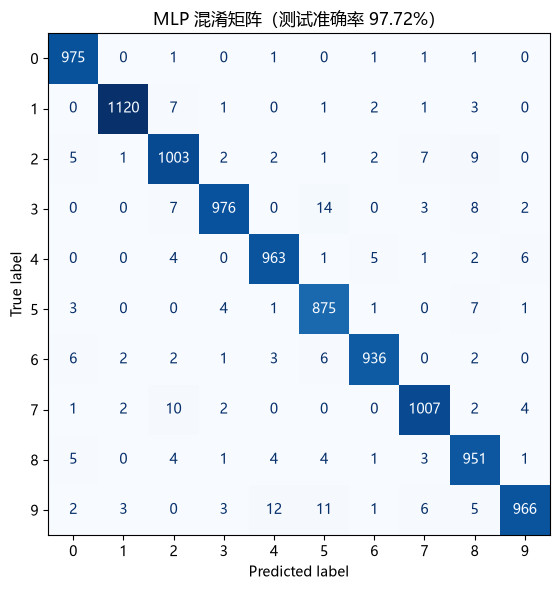

In [7]:
fig, acc = plot_confusion_matrix(mlp, test_loader, torch.device("cpu"), "outputs", "mlp")
print(f"MLP 测试集准确率: {acc:.2%}")

## 7. 打开黑盒：网络学到了什么

把 MLP 第一层 128 个神经元的权重画出来。每个小图是“一个神经元对 28x28 位置的偏好”——红色区域表示它希望那里有笔迹。你会发现网络真的学出了类似“横、竖、圈、斜线”的笔画模板。

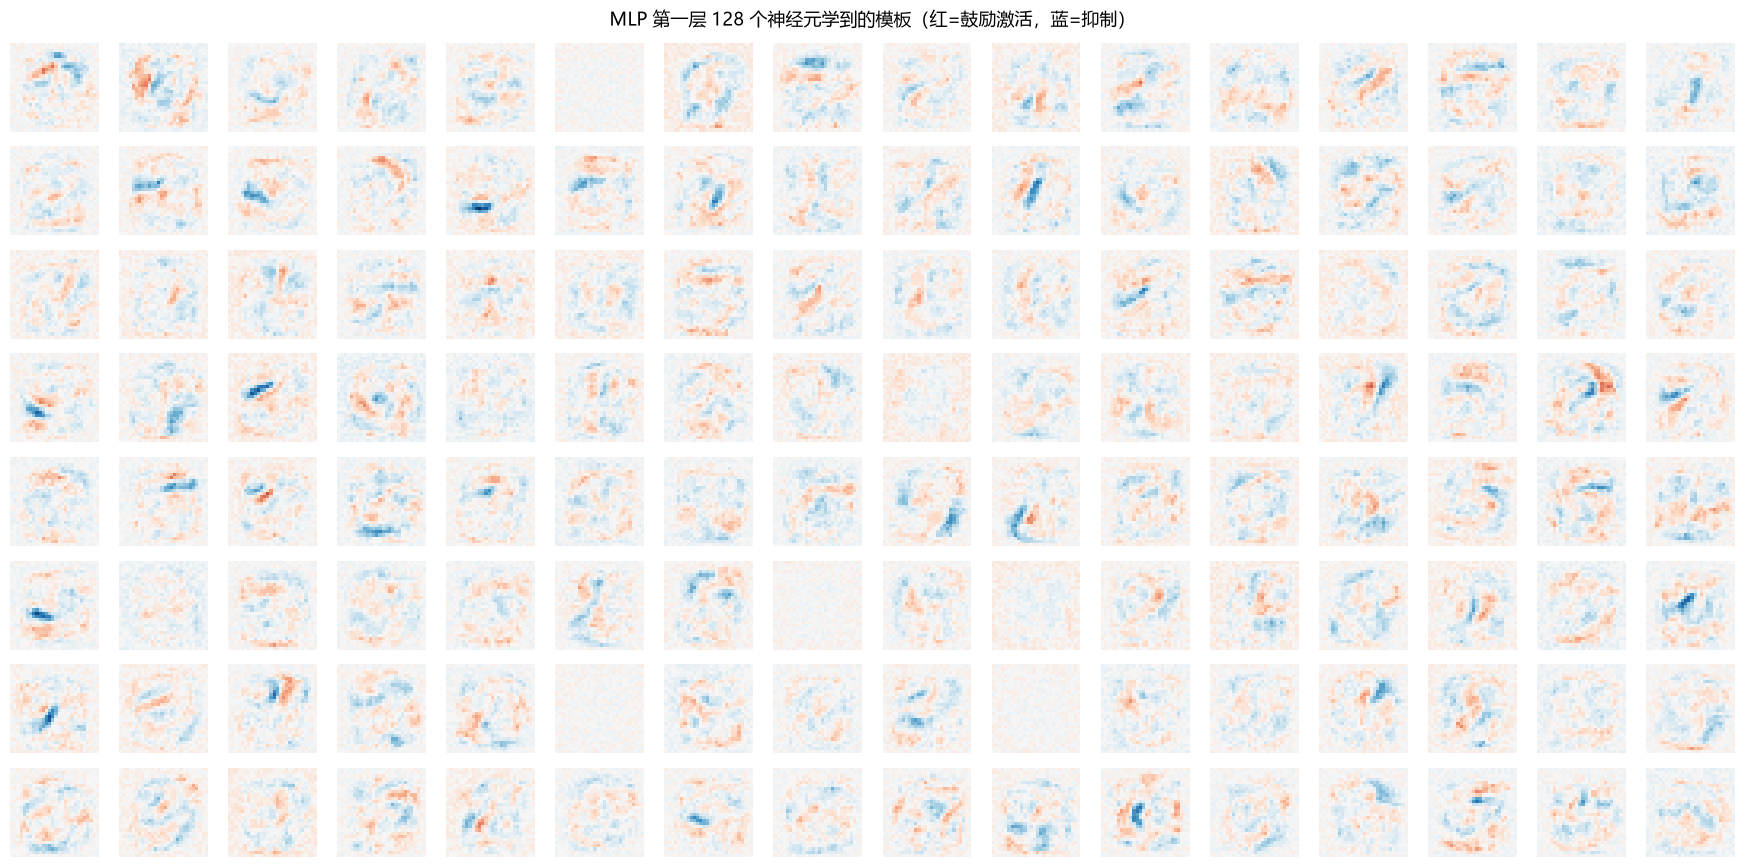

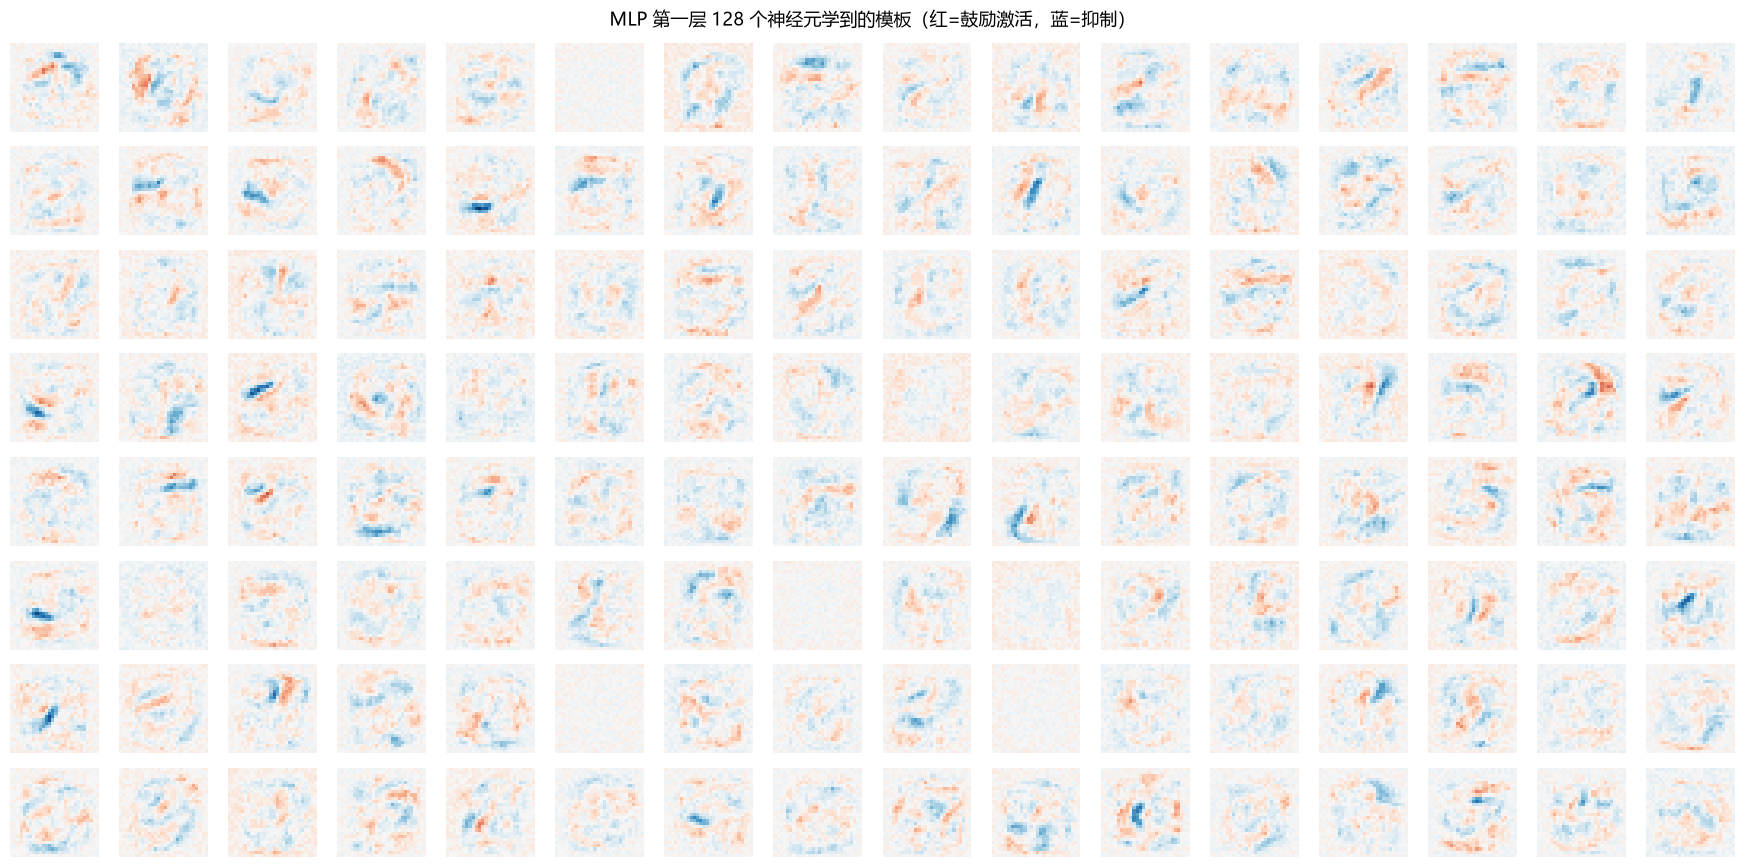

In [8]:
plot_mlp_weights(mlp, "outputs", "mlp")

## 8. 卷积网络（CNN）：让模型“看”图像

MLP 把图片拉平成一串数字，忽略了“相邻像素”的关系。CNN 用**卷积核**（小模板）在图片上滑动，天然保留空间结构：

- 卷积核 = 自动学到的特征模板（边缘、弧线）
- 池化 = 压缩尺寸、保留关键信息
- 多个卷积层 = 先找局部特征，再组合成笔画，最后分类

下面直接加载或训练 CNN，然后看它内部的卷积核和特征图。

In [9]:
cnn = build_model("cnn")
print(cnn)

ckpt = Path("outputs/cnn_mnist.pth")
if ckpt.exists():
    cnn.load_state_dict(torch.load(ckpt, map_location="cpu"))
    print("已加载预训练模型 outputs/cnn_mnist.pth（跳过训练）")
else:
    from src.train import train
    import argparse
    cnn, history = train(argparse.Namespace(
        model="cnn", epochs=3, batch_size=64, lr=1e-3,
        seed=42, data_dir="data", output_dir="outputs",
    ))
    plot_history(history, "outputs", "cnn")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
已加载预训练模型 outputs/cnn_mnist.pth（跳过训练）


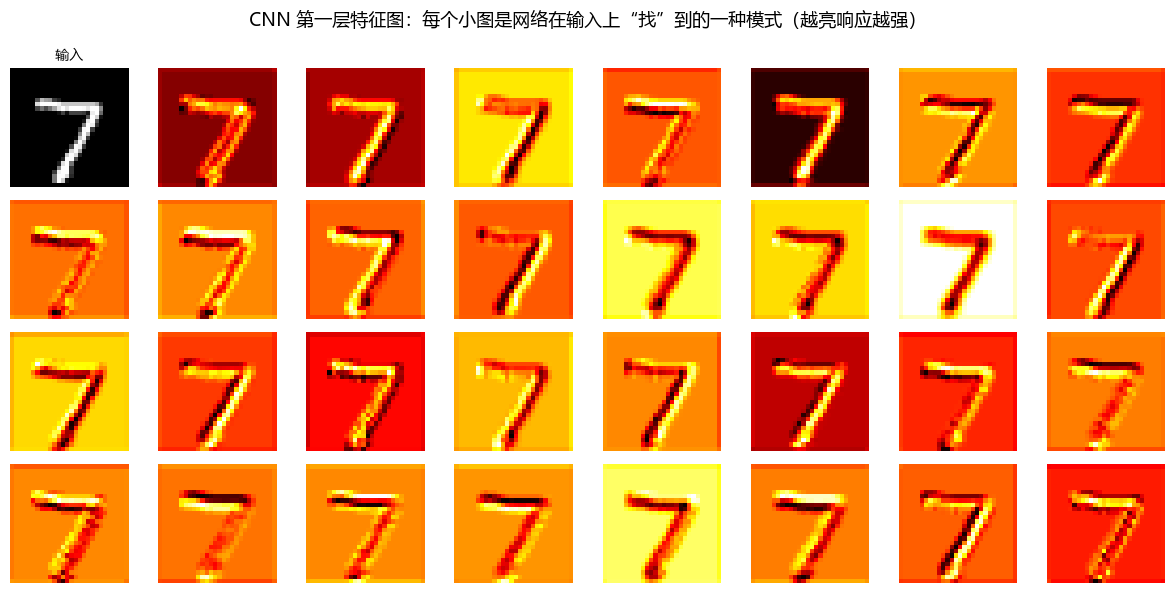

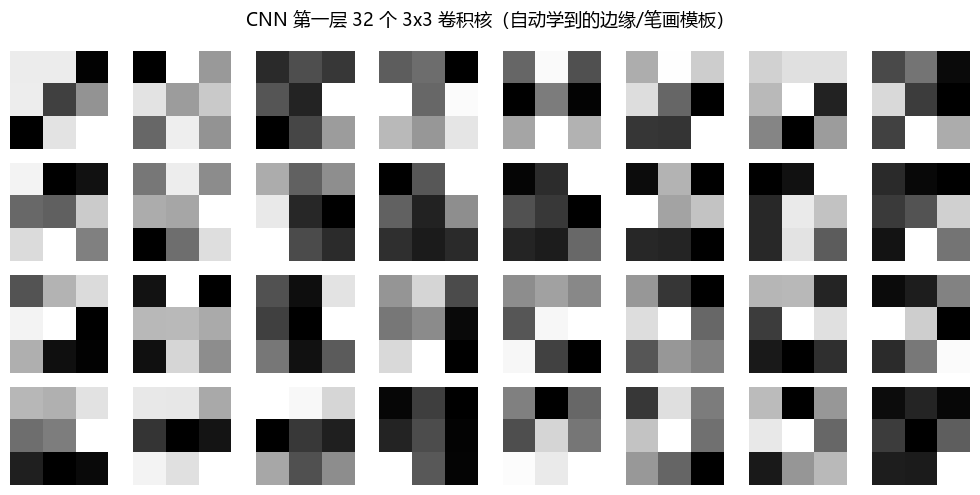

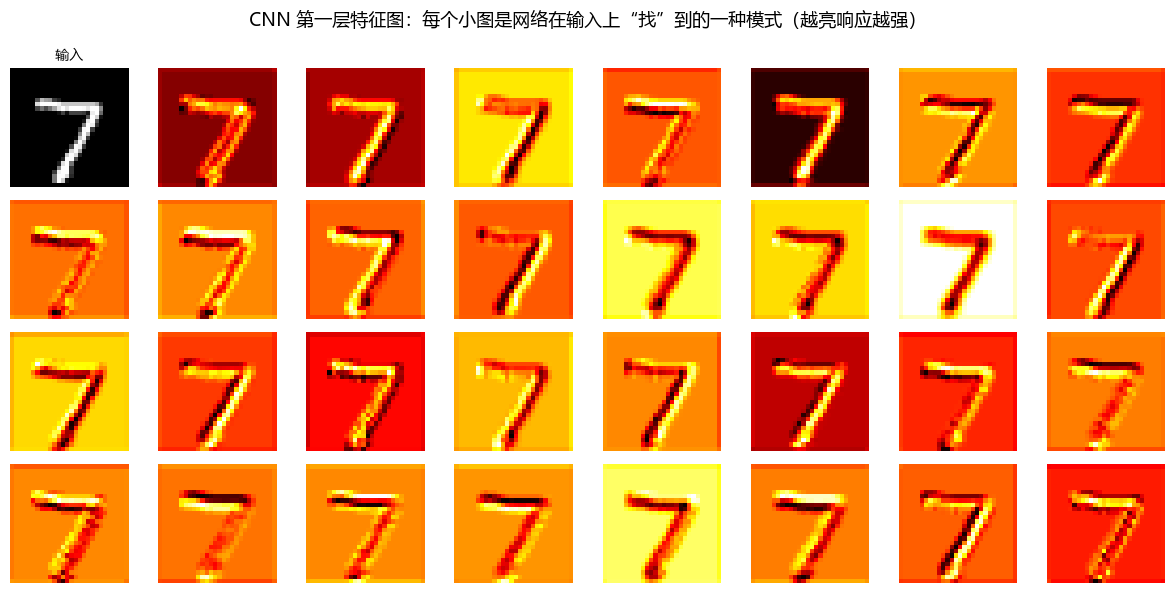

In [10]:
plot_cnn_filters_and_features(cnn, test_loader, torch.device("cpu"), "outputs", "cnn")

CNN 测试集准确率: 98.93%


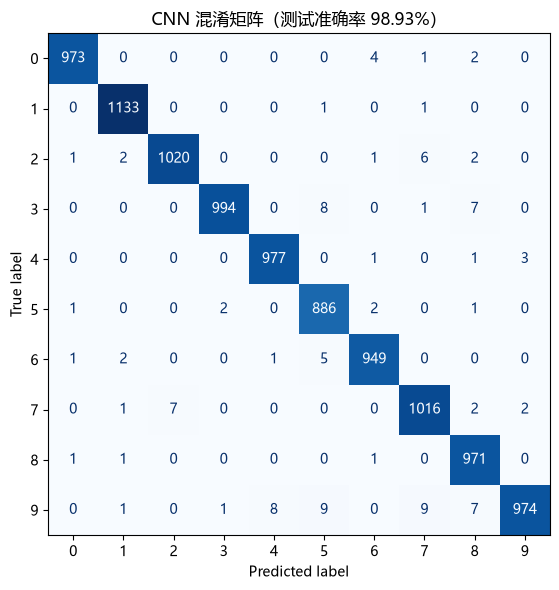

In [11]:
fig, acc = plot_confusion_matrix(cnn, test_loader, torch.device("cpu"), "outputs", "cnn")
print(f"CNN 测试集准确率: {acc:.2%}")

## 9. 总结与制造场景延伸

**一句话总结：深度学习 = 用数据自动调参数。** 我们做的每一件事，在工业场景里都有对应：

| 本项目的概念 | 制造场景的对应 |
| --- | --- |
| 手写数字 0~9 分类 | 产品表面缺陷分类（良品/划痕/污渍/破损） |
| 28x28 灰度图 | 工业相机拍的产品图像（需先统一尺寸） |
| 训练集 6 万张带标签 | 需要采集并人工标注的缺陷样本 |
| 测试集准确率 | 上线前的验收指标（漏检率/误报率） |
| 混淆矩阵 | 看哪些缺陷类型容易被混，针对性补数据 |
| 数据分布决定模型能力 | “训练数据长什么样，模型就学什么样” |

**延伸练习（建议）**：把 `datasets.MNIST` 换成 `datasets.FashionMNIST`，模型代码一行都不用改，体验从“数字识别”到“服装分类”的迁移。